- ### Numerical calculation

1. [Solving non-linaer system of equations](#solving-non-linaer-system-of-equations)

    1.1. Newton–Raphson Method

    1.2. Broyden’s Method

    1.3. Gradient-based root finding
    
    1.4. Fixed-Point Iteration

2. [Solving linear system of equations](#solving-linear-system-of-equations)

    2.1. General algorithm

    2.1.1. Gaussian elimination (to upper triangular matrix)

    2.1.2. Gauss–Jordan elimination (to identity matrix)

    2.1.3. LU decomposition
    
    2.1.4. Singular value decomposition

    2.1.5. pseudoinverse

    2.1.6. QR decomposition

    2.1.7. Jacobi method

    2.1.8. Gauss–Seidel method
    
    2.2. Symmetric positive definite matrix

    2.2.1. Cholesky decomposition

    2.3. Least squares

    2.3.1. Conjugate gradient method
    
3. [Calculating eigenvalue and eigenvector](#calculating-eigenvalue-and-eigenvector) 

    3.1. Characteristic Polynomial

    3.2. QR decomposition

    3.3. Power Method

4. [Affine transformation](#affine-transformation)

    4.1. Scaling & rotation & translation 
    
    4.2. Reflection along a (normal) vector

5. [Solving PDE](#solving-pde)

    5.1. Heat Equation

    5.1.1. Forward-Time Central-Space, FTCS

    5.1.2. Implicit Crank–Nicolson

    5.2. Wave Equation

    5.2.1. Forward-Time Central-Space, FTCS

    5.3. Poisson Equation

    5.3.1 Gauss–Seidel


---

- ### Solving non-linaer system of equations

Suppose we have $\bm{f(\bm{x})}=(f_1(\bm{x}), f_2(\bm{x})\dots,f_n(\bm{x}))^T: \mathbb{R}^n \rightarrow \mathbb{R}^n$, where 
$\bm{\bm{x}}=(x_1, x_2, \ldots, x_n)$.
Solve
$$\bm{f}(\bm{x})=0.$$

i.e.:

$$
\left\{\begin{array}{c}
f_1\left(x_1, x_2, \ldots, x_n\right)=0, \\
f_2\left(x_1, x_2, \ldots, x_n\right)=0, \\
\vdots \\
f_n\left(x_1, x_2, \ldots, x_n\right)=0 .
\end{array}\right.
$$

**Newton–Raphson Method:**

$$
\bm{x}_{k+1}=\bm{x}_k-J_f\left(\bm{x}_k\right)^{-1} \bm{f}\left(\bm{x}_k\right),
$$
where $J_f(\bm{x})$ is the Jacobian matrix:
$$
\left[J_f\right]_{i j}=\frac{\partial f_i}{\partial x_j}.
$$

Steps:
1. Choose initial guess $x_0$.
2. Compute $f\left(x_k\right)$ and $J_f\left(x_k\right)$.
3. Solve $J_f\left(x_k\right) \Delta x=f\left(x_k\right)$.
4. Update $x_{k+1}=x_k-\Delta x$.
5. Repeat until $\left\|f\left(x_k\right)\right\|<\varepsilon_0$.


In [1]:
from sympy import symbols, diff
def Newton(f,x0):
    y=x0
    for i in range(5):
        df_dx=diff(f,x)
        y=y-f.subs(x,y)/df_dx.subs(x,y)
    return y
x=symbols('x')
f=5*x**3+3*x**2-7*x+11
x0=1
x=round(Newton(f,x0),3)
print("x=",x)

x= 4.680


In [ ]:
import numpy as np
from sympy import symbols, diff
    
def newton_system(F, x0, tol=1e-10, max_iter=50):
    x = np.array(x0, dtype=float)

    for k in range(max_iter):
        Fx = np.array(F(x), dtype=float)
        Jx = np.array(J(x), dtype=float)

        # Solve J Δx = F
        delta = np.linalg.solve(Jx, Fx)
        x_new = x - delta

        if np.linalg.norm(x_new - x, ord=2) < tol:
            return x_new, k + 1

        x = x_new

    raise RuntimeError("Did not converge")

def F(vec): # objective fuction
    global expr
    global variables
    variables = symbols('x1:' + str(len(vec)+1)) # define symbolic variables x1:n
    expr = [variables[0]**2 + variables[1] + 1, variables[0] + variables[1] + 1]
    return [expr_comp.subs(subs_dict(variables, vec)) for expr_comp in expr]

def J(vec): # Jacobian matrix
    Jacobi = []
    for comp in expr:
        jacobian_row = [diff(comp, var).subs(subs_dict(variables, vec)) for var in variables]
        Jacobi.append(jacobian_row)
    return Jacobi

def subs_dict(variables, vec): # create substitution dictionary
    return {variables[i]: vec[i] for i in range(len(variables))}

solution, iters = newton_system(F, x0=[2, 1])
print("Solution =", solution, "\nIterations =", iters)


Solution = [ 1. -2.] 
Iterations = 7


**Gradient-based root finding:**

Equivalently optimizing:

$$arg\min_{\bm{x}} \|\bm{f}(\bm{x})\|^2$$

In [ ]:
import numpy as np
from sympy import symbols

def Gradient_based(f,x_min,x_max):
    return particle_swarm(norm_sqr, x_min, x_max)

def particle_swarm(f,x_min,x_max,n_particles=20,kmax=50,w=0.5,c1=1,c2=1,tol=1e-10):
    particles = np.random.uiform(x_min, x_max, (n_particles, len(x_min)))
    velocities = np.random.uiform(-abs(x_max - x_min), abs(x_max - x_min), (n_particles, len(x_min)))
    person_best = particles.copy()
    global_best = particles[np.argmin([f(p) for p in particles])]

    # Optimization loop
    for k in range(kmax):
        for i in range(n_particles):
            r1, r2 = np.random.rand(), np.random.rand()
            velocities[i] = (w * velocities[i] +
                             c1 * r1 * (person_best[i] - particles[i]) +
                             c2 * r2 * (global_best - particles[i]))
            particles[i] += velocities[i]

            # Update personal best
            if f(particles[i]) < f(person_best[i]):
                person_best[i] = particles[i]

        # Update global best
        current_global_best = particles[np.argmin([f(p) for p in particles])]
        if f(current_global_best) < f(global_best):
            global_best = current_global_best
        if f(global_best) < tol:
            return global_best
    
    raise RutimeError("Did not converge")

def f(vec): # objective fuction
    global expr
    global variables
    variables = symbols('x1:' + str(len(vec)+1)) # define symbolic variables x1:n
    expr = [variables[0]**2 + variables[1] + 1, variables[0] + variables[1] + 1]
    return np.array([expr_comp.subs(subs_dict(variables, vec)) for expr_comp in expr], dtype=float)

def norm_sqr(vec):
    return np.array(sum(com**2 for com in f(vec)), dtype=float)

def subs_dict(variables, vec): # create substitution dictionary
    return {variables[i]: vec[i] for i in range(len(variables))}

x_min = np.array([-1,-1])
x_max = np.array([1,1])
x_zeros = Gradient_based(f,x_min,x_max)
print("Zeros foud:", x_zeros)

Zeros found: [-4.94540114e-06 -1.00000258e+00]


**Broyden’s Method:**

Approximate the Jacobian matrix $J_f(\bm{x}_k)$ by $B_k$.

$$
\bm{x}_{k+1}=\bm{x}_k-B_k^{-1} \bm{f}\left(\bm{x}_k\right),
$$
$$
B_{k+1}=B_k+\frac{\left(\bm{y}_k-B_k \bm{s}_k\right) \bm{s}_k^T}{\bm{s}_k^T \bm{s}_k},
$$

And further no inverse form:

$$
\bm{x}_{k+1}=\bm{x}_k-H_k \bm{f}\left(\bm{x}_k\right),
$$

$$
H_{k+1}=H_k+\frac{\left(\bm{s}_k-H_k \bm{y}_k\right) \bm{s}_k^TH_k}{\bm{s}_k^TH_k \bm{y}_k},
$$

where
$$
\bm{s}_k=\bm{x}_{k+1}-\bm{s}_k, \quad \bm{y}_k=\bm{f}\left(\bm{x}_{k+1}\right)-\bm{f}\left(\bm{x}_k\right), \quad H_k=B_k^{-1}.
$$
Steps:
1. Choose initial $x_0$ and initial $B_0=I$
2. Solve $B_k \Delta x_k=f\left(x_k\right)$ or $\Delta x_k=H_k f\left(x_k\right)$
3. $x_{k+1}=x_k-\Delta x_k$
4. Compute $y_k=f\left(x_{k+1}\right)-f\left(x_k\right)$
5. Update $B_{k+1}=B_k+\frac{\left(y_k-B_k s_k\right) s_k^T}{s_k^T s_k}$ or $H_{k+1}=H_k+\frac{\left(\bm{s}_k-H_k \bm{y}_k\right) \bm{s}_k^TH_k}{\bm{s}_k^TH_k \bm{y}_k}$ 
6. Stop if $\left\|f\left(x_{k+1}\right)\right\| \leq \varepsilon_0$.

In [44]:
import numpy as np

def broyden(F, x0, tol=1e-6, max_iter=50):
    x = x0.astype(float)
    n = len(x)

    # Initial Jacobian approximation = identity
    B = np.eye(n)
    Fx = F(x)

    for k in range(max_iter):
        # Solve B s = -F(x)
        try:
            s = np.linalg.solve(B, -Fx)
        except np.linalg.LinAlgError:
            raise ValueError("Jacobian approximation became singular at iteration %d" % k)

        # Update x
        x_new = x + s
        Fx_new = F(x_new)

        # Check convergence
        if np.linalg.norm(Fx_new) < tol:
            print(f"Converged in {k+1} iterations.")
            return x_new

        # Compute update quantities
        y = Fx_new - Fx
        Bs = B @ s
        denom = np.dot(s, s)

        # Broyden rank-1 update
        B = B + np.outer((y - Bs), s) / denom

        x, Fx = x_new, Fx_new

    print("Warning: Maximum iterations reached.")
    return x

def F(vec): # objective function
    global expr
    global variables
    variables = symbols('x1:' + str(len(vec)+1)) # define symbolic variables x1:n
    expr = [variables[0]**2 + variables[1] + 1, variables[0] + variables[1] + 1]
    return np.array([expr_comp.subs(subs_dict(variables, vec)) for expr_comp in expr], dtype=float)

def subs_dict(variables, vec): # create substitution dictionary
    return {variables[i]: vec[i] for i in range(len(variables))}

x0 = np.array([2.0, 1.0])
solution = broyden(F, x0)
print("Solution found by Broyden's method:", solution)

Converged in 14 iterations.
Solution found by Broyden's method: [-7.07841413e-09 -9.99999993e-01]


**Fixed-Point Iteration:**

If $f(x)$ can be written as $f(x)=g(x)-x$, then $f(x)=0 \Leftrightarrow g(x)=x$.

$$x_{k+1}=g(x_k)$$

Convergence Condition:

$$\rho(J_g(x^*))<1,$$

where $\rho$ is spectral radius of the Jacobian $J_g$.

In [45]:
import math

def fixed_point(g, x0, tol=1e-8, max_iter=100):
    x = x0
    for k in range(max_iter):
        x_new = g(x)
        if abs(x_new - x) < tol:
            return x_new, k+1
        x = x_new
    raise ValueError("Did not converge")

g = lambda x: math.cos(x)
root, iterations = fixed_point(g, x0=1.0)

print("Root =", root)
print("Iterations:", iterations)


Root = 0.7390851366465718
Iterations: 46


---

- ### Solving linear system of equations

$$A\bm{x}=\bm{b},$$

where $A\in \mathbb{R}^{m\times n}$, $\bm{b}\in \mathbb{R}^m$.

**Gaussian Elimination (to upper triangular matrix):**

Steps:

1. Forward elimination

For each column $j=1, \ldots, n$, find a pivot such that $A_{i_{j}j}\neq 0$,
and swap row $i_{j}$ and $j$.

For each pivot row $i$, eliminate all entries below $A_{i i}$.
$$
A_{k j}=A_{k j}-\frac{A_{k i}}{A_{i i}} A_{i j}, \quad b_k=b_k-\frac{A_{k i}}{A_{i i}} b_i
$$
for $k=i+1, \ldots, n$.

Backward substitution:

Once $A$ is upper-triangular $U$ :
$$
x_i=\frac{1}{U_{i i}}\left(b_i-\sum_{j=i+1}^n U_{i j} x_j\right)
$$

for $i=n, n-1, \ldots, 1$.

In [2]:
def Gauss(A, b):
    m,n = len(A),len(A[0])
    for j in range(n):
        row_max_id = [i for i in range(j, m) if A[i][j] == max([A[i][j] for i in range(j, m)])][0]
        if A[row_max_id][j] == 0:
            continue
        if row_max_id != j:
            A[j], A[row_max_id] = A[row_max_id], A[j]
            b[j], b[row_max_id] = b[row_max_id], b[j]
        for i in range(j+1, m):
            if A[i][j] == 0:
                continue
            factor = A[i][j] / A[j][j]
            for k in range(j, n):
                A[i][k] -= factor * A[j][k]
            b[i] -= factor * b[j]
    x = [0 for _ in range(n)]
    x[n-1] = b[n-1] / A[n-1][n-1]
    for i in range(n-2, -1, -1):
        sum_ax = sum(A[i][j] * x[j] for j in range(i+1, n))
        x[i] = (b[i] - sum_ax) / A[i][i]
    return x

A = [[2, 1, -1],
     [-3, -1, 2],
     [-2, 1, 2]]
b = [8, -11, -3]
x = Gauss(A, b)
print("Solution:", x)

Solution: [2.0, 3.0, -1.0]


In [4]:
import numpy as np
A_np = np.array([[2, 1, -1],
                 [-3, -1, 2],
                 [-2, 1, 2]], dtype=float)
b_np = np.array([8, -11, -3], dtype=float)
x_np = np.linalg.solve(A_np, b_np)
print("Numpy Solution:", x_np)

Numpy Solution: [ 2.  3. -1.]


**Gauss–Jordan elimination (to identity matrix):**

Steps:

1. Elimination

For each column $j=1, \ldots, n$, find a pivot such that $A_{i_{j}j}\neq 0$, and swap row $i_{j}$ and $j$.

For each pivot row $i$, normalize the pivot by $A_{ij}=A_{ij}/A_{ii}$, and then eliminate all entries besides $A_{i i}$.
$$
A_{k j}=A_{k j}-A_{k i} A_{i j}, \quad b_k=b_k-A_{k i} b_i
$$
for $k=1, \ldots, i-1, i+1, \ldots, n$.



In [ ]:
def Gauss_Jordan(A, b):
    m,n = len(A),len(A[0])
    for j in range(n):
        row_max_id = [i for i in range(j, m) if A[i][j] == max([A[i][j] for i in range(j, m)])][0]
        if A[row_max_id][j] == 0:
            continue
        if row_max_id != j:
            A[j], A[row_max_id] = A[row_max_id], A[j]
            b[j], b[row_max_id] = b[row_max_id], b[j]
            A[j] = [elem / A[j][j] for elem in A[j]]
        for i in range(m) if i != j else []:
            if A[i][j] == 0:
                continue
            for k in range(j, n):
                A[i][k] -= A[i][j] * A[j][k]
            b[i] -= A[i][j] * b[j]
    return b

A = [[2, 1, -1],
     [-3, -1, 2],
     [-2, 1, 2]]
b = [8, -11, -3]
x = Gauss(A, b)
print("Solution:", x)

Solution: [2.0, 3.0, -1.0]


**LU decomposition:**
 $$A=LU$$
Step 1. 
Initialize
$$
L=I_n, \quad U=A
$$

Step 2. 
For each column $k=1,2, \ldots, n-1$:

For all rows $i=k+1, \ldots, n
-$:
1. Compute the multiplier
$$
l_{i k}=\frac{u_{i k}}{u_{k k}}
$$
2. Subtract from the lower rows:

For each column $j=1,2, \ldots, n-1$:
$$
u_{ij} = u_{ij}-l_{i k} u_{kj}
$$
3. Obtain L & U:

$$L=(l_{ij}), \quad U=(u_{ij}).$$

After elimination, $L$ is lower triangular and $U$ becomes upper triangular.

In [52]:
import numpy as np

def lu_decomposition(A):
    A = np.array(A, dtype=float)
    n = len(A)
    L = np.zeros((n,n))
    U = np.zeros((n,n))

    for i in range(n):
        # Upper
        for k in range(i, n):
            s = sum(L[i][j] * U[j][k] for j in range(i))
            U[i][k] = A[i][k] - s

        # Lower
        L[i][i] = 1
        for k in range(i+1, n):
            s = sum(L[k][j] * U[j][i] for j in range(i))
            L[k][i] = (A[k][i] - s) / U[i][i]
    
    return L, U

A = [[2,1,1],[4,-6,0],[-2,7,2]]
L, U = lu_decomposition(A)
print("L=\n", L)
print("U=\n", U)
print("check:\nLU=\n", L@U)

L=
 [[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1. -1.  1.]]
U=
 [[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  0.  1.]]
check:
LU=
 [[ 2.  1.  1.]
 [ 4. -6.  0.]
 [-2.  7.  2.]]


In [57]:
import numpy as np
from scipy.linalg import lu

A = np.array([[2, 1, 1],
              [4, -6, 0],
              [-2, 7, 2]], dtype=float)

P, L, U = lu(A)

print("P =\n", P)
print("L =\n", L)
print("U =\n", U)
print("check:\nPA=\n", P@A)
print("check:\nLU=\n", L@U)

P =
 [[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
L =
 [[ 1.   0.   0. ]
 [ 0.5  1.   0. ]
 [-0.5  1.   1. ]]
U =
 [[ 4. -6.  0.]
 [ 0.  4.  1.]
 [ 0.  0.  1.]]
check:
PA=
 [[ 4. -6.  0.]
 [ 2.  1.  1.]
 [-2.  7.  2.]]
check:
LU=
 [[ 4. -6.  0.]
 [ 2.  1.  1.]
 [-2.  7.  2.]]


**singular value decomposition:**

For any real matrix $A\in\mathbb{R}^{m×n}$:

$$A=U\Sigma V^{T}$$
Where $U\in\mathbb{O}(m)$, $V\in\mathbb{O}(n)$,

$\Sigma$: diagonal with singular values $\sigma_{1}≥\sigma_{2}≥\dotsc$


Singular values satisfy: 
$$\sigma_{i}=\sqrt{\lambda_{i}(A^{T}A)}$$

In [97]:
import numpy as np

def SVD(A):
    ATA = A.T @ A
    eigvals, V = np.linalg.eigh(ATA)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    S = np.sqrt(eigvals)

    # compute U = A V / sigma
    U = np.zeros((A.shape[0], A.shape[0]))
    for i in range(len(S)):
        if S[i] > 1e-10:
            U[:, i] = A @ V[:, i] / S[i]

    return U, S, V

A = np.array([[3, 1, 2],
              [-1, 3, 6]], dtype=float)
U, S, V = SVD(A)
print("U=\n", U)
print("S=\n", S)
print("V=\n", V)
print("check:\nU S V^T=\n", U @ np.diag(S)[:A.shape[0],:A.shape[1]] @ V.T)

U=
 [[ 0.31622777  0.9486833 ]
 [ 0.9486833  -0.31622777]]
S=
 [7.07106781 3.16227766 0.        ]
V=
 [[ 0.          1.          0.        ]
 [ 0.4472136   0.         -0.89442719]
 [ 0.89442719  0.          0.4472136 ]]
check:
U S V^T=
 [[ 3.  1.  2.]
 [-1.  3.  6.]]


**pseudoinverse:**

If the linear system is overdetermined or underdetermined

$$A\bm{x}=\bm{b},$$

where $A\in \mathbb{R}^{m\times n}$, $\bm{b}\in \mathbb{R}^m$,

then SVD gives the solution using pseudoinverse: 

$$A^{+}=V\Sigma^{+}U^{T}$$
$$x=A^{+}b$$

where $\Sigma^{+}$ has shape $\Sigma^{T}$ with diag $\{\sigma_1^{-1},\sigma_1^{-1},\dots,\sigma_n^{-1}\}$.

In [99]:
import numpy as np

def SVD(A):
    ATA = A.T @ A
    eigvals, V = np.linalg.eigh(ATA)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    S = np.sqrt(eigvals)

    # compute U = A V / sigma
    U = np.zeros((A.shape[0], A.shape[0]))
    for i in range(len(S)):
        if S[i] > 1e-10:
            U[:, i] = A @ V[:, i] / S[i]

    return U, S, V

def pseudoinverse(A):
    U, S, V = SVD(A)
    S_inv = np.zeros((A.shape[1], A.shape[0]))
    for i in range(len(S)):
        if S[i] > 1e-10:
            S_inv[i, i] = 1 / S[i]
    A_pinv = V @ S_inv @ U.T
    return A_pinv

def solve_least_squares(A, b):
    A_pinv = pseudoinverse(A)
    x = A_pinv @ b
    return x

A = np.array([[3, 1, 2],
              [-1, 3, 6]], dtype=float)
U, S, V = SVD(A)
print("U=\n", U)
print("S=\n", S)
print("V=\n", V)
print("check:\nU S V^T=\n", U @ np.diag(S)[:A.shape[0],:A.shape[1]] @ V.T)
A_pinv = pseudoinverse(A)
print("Pseudoinverse=\n", A_pinv)
b = np.array([1, 2], dtype=float)
x_ls = solve_least_squares(A, b)
print("Least squares solution x=\n", x_ls)

U=
 [[ 0.31622777  0.9486833 ]
 [ 0.9486833  -0.31622777]]
S=
 [7.07106781 3.16227766 0.        ]
V=
 [[ 0.          1.          0.        ]
 [ 0.4472136   0.         -0.89442719]
 [ 0.89442719  0.          0.4472136 ]]
check:
U S V^T=
 [[ 3.  1.  2.]
 [-1.  3.  6.]]
Pseudoinverse=
 [[ 0.3  -0.1 ]
 [ 0.02  0.06]
 [ 0.04  0.12]]
Least squares solution x=
 [0.1  0.14 0.28]


**QR decomposition:**

$$A=QR\quad \Leftrightarrow \quad Q^TA=R,$$
where 
$A\in\mathbb{R}^{m\times n}, Q\in O_{m\times n}(\mathbb{R})$, i.e., $Q^TQ=I_n$, $R\in \mathbb{R}^{n\times n}$ is upper triangular.

Gram–Schmidt Orthogonalization:

Let $A=[a_1, a_2, \ldots, a_n]$, $Q=[q_1, q_2, \ldots, q_n]$, then

$$a_j=r_{jj}q_j+\sum_{i=1}^{j-1}r_{ij}q_i,\quad q_i^Ta_j=r_{ij}.$$

Steps:

1. Initialize
$$u_1=a_1,$$
$$q_1=\frac{u_1}{\|u_1\|},\quad r_{11}=\|u_1\|.$$

2. For $k=2,3,\ldots,n:$

Project $a_k$ to previous $q_i$

$$r_{ik}=q_i^Ta_k,\quad i=1,2,\ldots,k-1.$$

Substract projections

$$u_k=a_k-\sum_{i=1}^{k-1}r_{ik}q_i,$$

Normalize

$$q_k=\frac{u_k}{\|u_k\|}, \quad r_{kk}=\|u_k\|.$$

In [58]:
def qr_decomposition(A):
    A = np.array(A, dtype=float)
    n, m = A.shape
    Q = np.zeros((n, m))
    R = np.zeros((m, m))

    for j in range(m):
        v = A[:, j]

        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            v = v - R[i, j] * Q[:, i]

        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]

    return Q, R

A = [[1,2,4],[3,8,14],[2,6,13]]
Q, R = qr_decomposition(A)

print("Q=\n", Q)
print("R=\n", R)
print("check:\nQR=\n", Q@R)

Q=
 [[ 0.26726124 -0.77151675  0.57735027]
 [ 0.80178373 -0.15430335 -0.57735027]
 [ 0.53452248  0.6172134   0.57735027]]
R=
 [[ 3.74165739 10.15592719 19.24280942]
 [ 0.          0.9258201   2.7774603 ]
 [ 0.          0.          1.73205081]]
check:
QR=
 [[ 1.  2.  4.]
 [ 3.  8. 14.]
 [ 2.  6. 13.]]


In [55]:
import numpy as np

A = np.array([[1,2,4],
              [3,8,14],
              [2,6,13]], float)

Q, R = np.linalg.qr(A)

print("Q =\n", Q)
print("R =\n", R)
print("check:\nQR=\n", Q@R)

Q =
 [[-0.26726124  0.77151675  0.57735027]
 [-0.80178373  0.15430335 -0.57735027]
 [-0.53452248 -0.6172134   0.57735027]]
R =
 [[ -3.74165739 -10.15592719 -19.24280942]
 [  0.          -0.9258201   -2.7774603 ]
 [  0.           0.           1.73205081]]
check:
QR=
 [[ 1.  2.  4.]
 [ 3.  8. 14.]
 [ 2.  6. 13.]]


**Jacobi method:**

If matrix $A$ is strictly diagonally dominant, i.e.: 
$$|a_{ii}|>\sum_{j≠i}|a_{ij}|$$
 Or if A is symmetric positive definite. then iterates

$$x_{i}^{(k+1)}=\frac{1}{a_{ii}}\left(b_{i}-\sum_{j≠i}a_{ij}x_{j}^{(k)}\right) ,\forall i$$

In [17]:
import numpy as np

def jacobi(A, b, x0=np.zeros(len(b)), tol=1e-6, max_iter=100):
    n = len(A)
    x = x0
    x_new = np.zeros(n)

    for k in range(max_iter):
        for i in range(n):
            s_c = sum(abs(A[i][j]) for j in range(n) if j != i)
            if abs(A[i][i]) <= s_c:
                raise ValueError("Matrix is not diagonally dominant, Jacobi method may not converge.")
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        # check stopping
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k+1

        x = x_new.copy()

    return x, max_iter

A = np.array([[4, -1, 0, 0],
                [-1, 4, -1, 0],
                [0, -1, 4, -1],
                [0, 0, -1, 3]], dtype=float)
b = np.array([15, 10, 10, 10], dtype=float)
x0 = np.zeros(len(b))
solution, iterations = jacobi(A, b, x0)
print("Jacobi Solution:", np.round(solution,2))
print("Jacobi Iterations:", iterations)

Jacobi Solution: [5. 5. 5. 5.]
Jacobi Iterations: 19


**Gauss–Seidel Method:**

updates each variable in-place compared with Jacobi method.

If matrix $A$ is strictly diagonally dominant, i.e.: 
$$|a_{ii}|>\sum_{j≠i}|a_{ij}|$$
 Or if A is symmetric positive definite. then iterates

$$x_{i}^{(k+1)}=\frac{1}{a_{ii}}\left(b_{i}-\sum_{j<i}a_{ij}x_{j}^{(k+1)}-\sum_{j>i}a_{ij}x_{j}^{(k)}\right) ,\forall i.$$

In [20]:
import numpy as np

def jacobi(A, b, x0=np.zeros(len(b)), tol=1e-6, max_iter=100):
    n = len(A)
    x = x0
    x_new = np.zeros(n)

    for k in range(max_iter):
        for i in range(n):
            s_c = sum(abs(A[i][j]) for j in range(n) if j != i)
            if abs(A[i][i]) <= s_c:
                raise ValueError("Matrix is not diagonally dominant, Jacobi method may not converge.")
            s1 = sum(A[i][j] * x_new[j] for j in range(n) if j < i)
            s2 = sum(A[i][j] * x[j] for j in range(n) if j > i)
            x_new[i] = (b[i] - s1 -s2) / A[i][i]

        # check stopping
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k+1

        x = x_new.copy()

    return x, max_iter

A = np.array([[4, -1, 0, 0],
                [-1, 4, -1, 0],
                [0, -1, 4, -1],
                [0, 0, -1, 3]], dtype=float)
b = np.array([15, 10, 10, 10], dtype=float)
x0 = np.zeros(len(b))
solution, iterations = jacobi(A, b, x0)
print("Jacobi Solution:", np.round(solution,2))
print("Jacobi Iterations:", iterations)

Jacobi Solution: [5. 5. 5. 5.]
Jacobi Iterations: 11


**Cholesky Decomposition:**

If matrix $A\in \mathbb{R}^{m\times n}$ is symmetric, positive-definite, then it has Cholesky Decomposition $$A=LL^T,$$

where $L$ is a lower-triangular matrix.

Diagonal element $L_{ii}$:
$$L_{ii}=\sqrt{A_{ii}-\sum_{k=1}^{i-1}L_{ik}^{2}}$$

Off-diagonal element $L_{ij}$ for i>j:
$$L_{ij}=\frac{1}{L_{jj}}\left(A_{ij}-\sum_{k=1}^{j-1}L_{ik}L_{jk}\right)$$

Off-diagonal element $L_{ij}$ for i<j:
$$L_{ij}= 0.$$

In [63]:
import numpy as np

def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1):
            sum_val = np.dot(L[i, :j], L[j, :j])
            if i == j:
                L[i, j] = np.sqrt(A[i, i] - sum_val)
            else:
                L[i, j] = (A[i, j] - sum_val) / L[j, j]
    return L

A = np.array([[4,12,-16],[12,37,-43],[-16,-43,98]], dtype=float)
L = cholesky_decomposition(A)
print("L =\n", L)
print("Check L L^T =\n", L @ L.T)

L =
 [[ 2.  0.  0.]
 [ 6.  1.  0.]
 [-8.  5.  3.]]
Check L L^T =
 [[  4.  12. -16.]
 [ 12.  37. -43.]
 [-16. -43.  98.]]


**Conjugate Gradient:**

To approximate solution of $Ax=b$ with $A\in \mathbb{R}^{m\times n}$ and $m\gg n$, the problem can be thought as a linear least squares problem: 
$$\min_{x}\| Ax-b\|^{2},$$

Or equivalently:
$$\min_{x}f(x)=\frac{1}{2}x^{T}A^{T}Ax-A^{T}bx,$$

then the sufficient condition is: 
$$\nabla f(x)=A^{T}Ax-A^{T}b=0.$$

Steps:
1. Initialize

$$x_{0}=x_{0}$$
$$r_{0}=A^{T}(b-Ax_{0})$$
$$p_{0}=r_{0}$$

2. For $k=0, 1, \ldots$ until $r_{k}<\varepsilon_0$:

$$\alpha_{k}=\frac{r_{k}^{T}r_{k}}{p_{k}^{T}A^{T}Ap_{k}}$$

$$x_{k+1}=x_{k}+\alpha_{k}p_{k}$$
 
$$r_{k+1}=r_{k}-\alpha_{k}A^{T}Ap_{k}$$
 
$$\beta_{k}=\frac{r_{k+1}^{T}r_{k+1}}{r_{k}^{T}r_{k}}$$
 
$$p_{k+1}=r_{k+1}+\beta_{k}p_{k}.$$

In [64]:
import numpy as np

def cg_least_squares(A, b, tol=1e-8, max_iter=500):
    m, n = A.shape
    x = np.zeros(n)

    # r0 = A^T (b - Ax)
    r = A.T @ (b - A @ x)
    p = r.copy()

    for k in range(max_iter):
        Ap = A @ p
        AtAp = A.T @ Ap

        rTr = np.dot(r, r)
        alpha = rTr / np.dot(Ap, Ap)

        x = x + alpha * p
        r_new = r - alpha * AtAp

        if np.linalg.norm(r_new) < tol:
            break

        beta = np.dot(r_new, r_new) / rTr
        p = r_new + beta * p
        r = r_new

    return x, k+1

A = np.array([[3,2],[2,6],[1,1]], dtype=float)
b = np.array([2, -8, 0], dtype=float)
x, iterations = cg_least_squares(A, b)
print("CG Least Squares Solution:", np.round(x,3))
print("CG Least Squares Iterations:", iterations)

CG Least Squares Solution: [ 2. -2.]
CG Least Squares Iterations: 2


In [100]:
import numpy as np

def SVD(A):
    ATA = A.T @ A
    eigvals, V = np.linalg.eigh(ATA)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    S = np.sqrt(eigvals)

    # compute U = A V / sigma
    U = np.zeros((A.shape[0], A.shape[0]))
    for i in range(len(S)):
        if S[i] > 1e-10:
            U[:, i] = A @ V[:, i] / S[i]

    return U, S, V

def pseudoinverse(A):
    U, S, V = SVD(A)
    S_inv = np.zeros((A.shape[1], A.shape[0]))
    for i in range(len(S)):
        if S[i] > 1e-10:
            S_inv[i, i] = 1 / S[i]
    A_pinv = V @ S_inv @ U.T
    return A_pinv

def solve_least_squares(A, b):
    A_pinv = pseudoinverse(A)
    x = A_pinv @ b
    return x

A = np.array([[3,2],[2,6],[1,1]], dtype=float)
b = np.array([2, -8, 0], dtype=float)
x_ls = solve_least_squares(A, b)
print("Least squares solution x=\n", x_ls)

Least squares solution x=
 [ 2. -2.]


---

- ### Calculating eigenvalue and eigenvector

Suppose $A\in\mathbb{R}^{n\times n}$, $\lambda_i$ is egien-values of $A$, and $x_i$ is egien-vector of $A$ with respect to $\lambda_i$, then

$$Ax_i=\lambda_i x_i.$$

Let 
$$Q=[x_1, \dots, x_n]$$

$$\Lambda=diag\{x_1, \dots, x_n\}$$

Then $$A=Q\Lambda Q^{-1}.$$

**Characteristic Polynomial:**

Given a matrix A, the characteristic polynomial is:

$$p(\lambda)=\text{det}(\lambda I-A)$$

If 

$$p(\lambda)=\lambda^{n}+c_{1}\lambda^{n-1}+c_{2}\lambda^{n-2}+\cdots +c_{n}$$
    
Then by Faddeev–LeVerrier Formula,

$$c_{k}=-\frac{1}{k}\sum_{j=0}^{k-1}c_{j}\cdot\operatorname{tr}(A^{k-j}),\ k=1,2,\dots,n$$

Solve polynomial equation for eigen-values:

$$p(\lambda)=0$$

Solve system of linear euqation for eigen-vectors:

$$(A-\lambda I)x=0$$

In [101]:
import numpy as np

def characteristic_polynomial(A):
    n = A.shape[0]
    coeffs = [1]           # Coefficient for λ^n
    Bk = np.eye(n)         # B_0 = I

    for k in range(1, n + 1):
        Bk = A @ Bk        # B_k = A B_{k-1}
        ck = -np.trace(Bk) / k
        coeffs.append(ck)
        Bk = Bk + ck * np.eye(n)   # Update B_k for next iteration

    return coeffs

def eigenvalues(A):
    coeffs = characteristic_polynomial(A)
    return np.roots(coeffs)

def eigenvectors(A):
    vals = eigenvalues(A)
    vecs = []
    for val in vals:
        M = A - val * np.eye(A.shape[0])
        _, _, vh = np.linalg.svd(M)
        vecs.append(vh[-1])    # eigenvector = singular vector with smallest σ, i.e. σ=0 
    return np.array(vecs).T    # columns are eigenvectors

A = np.array([[-4, -2, 6],
              [ 1, -3, 9],
              [-2,  4, -2]], dtype=float)

print("Characteristic Polynomial Coefficients:", characteristic_polynomial(A))
print("Eigenvalues:", eigenvalues(A))
Q = eigenvectors(A)
print("Eigenvectors:\n", Q)
print("Q^-1 A Q:\n", np.linalg.inv(Q) @ A @ Q)

Characteristic Polynomial Coefficients: [1, np.float64(9.0), np.float64(4.0), np.float64(-140.0)]
Eigenvalues: [-6.11224453+2.46134071j -6.11224453-2.46134071j  3.22448907+0.j        ]
Eigenvectors:
 [[ 0.807902  +0.j          0.807902  +0.j          0.22157113+0.j        ]
 [ 0.4157114 +0.32059839j  0.4157114 -0.32059839j  0.81336247+0.j        ]
 [-0.14584396-0.22455422j -0.14584396+0.22455422j  0.53791052+0.j        ]]
Q^-1 A Q:
 [[-6.11224453e+00-2.46134071e+00j -8.88178420e-16-8.88178420e-16j
  -5.65510124e-17-2.37123333e-15j]
 [-2.22044605e-15+4.44089210e-16j -6.11224453e+00+2.46134071e+00j
   4.38045156e-16+2.37123333e-15j]
 [ 1.48690677e-15-2.20080209e-16j  1.72875387e-15+3.62120202e-16j
   3.22448907e+00-4.34606192e-17j]]


**QR decomposition:**

1. Initialize

$$A_{(1)}=A$$

2. For $i = 1,2, \dots$

$$A_{(i)}=Q_{(i)}R_{(i)}$$

$$A_{(i+1)}=Q_{(i)}^TA_{(i)}Q_{(i)}=R_{(i)}Q_{(i)}$$

When $i\rightarrow \infty$, 

$$A_{(i)}\rightarrow \left[ \begin{array}{l l l l}
{\lambda_{1}} & { \cdots } & {\cdots} \\
{0} & {\lambda_{2}} & { \cdots }\\
 & \vdots \\
{0} & {0} & {\lambda_{n}} \end{array} \right],$$

where $\lambda_{i}$ are eigen-values.

Solve system of linear euqation for eigen-vectors:

$$(A-\lambda_i I)v_i=0$$

In [62]:
A = np.array([[3,2],[2,6],[1,1]], dtype=float)
b = np.array([2, -8, 0], dtype=float)
Q, R = np.linalg.qr(A)
print("Q =\n", Q)
print("R =\n", R)
print("check:\nQR=\n", Q@R)

x = np.linalg.solve(R, Q.T @ b)
print("Least-squares solution:", x)

Q =
 [[-0.80178373  0.53106072]
 [-0.53452248 -0.84237217]
 [-0.26726124  0.09156219]]
R =
 [[-3.74165739 -5.0779636 ]
 [ 0.         -3.90054941]]
check:
QR=
 [[3. 2.]
 [2. 6.]
 [1. 1.]]
Least-squares solution: [ 2. -2.]


**Power Method:**

1. Initialize

$$A_{(1)}=A$$

Suppose matrix A has eigenpairs: 
$$A_{(1)}v_{i}=\lambda_{i}v_{i}$$

with $|\lambda_{i}|>|\lambda_{j}|$ for any $i < j$, then for any vector decomposition: 
$$x_{0}=c_{1}v_{1}+c_{2}v_{2}+\cdots$$

$$x_{k}=A_{(1)}^kx_{0}=c_{1}\lambda_{1}^{k}v_{1}+c_{2}\lambda_{2}^{k}v_{2}+\cdots$$

When $k\rightarrow \infty$, this approximate $\lambda_{1}$ and $v_{1}$:

$$\frac{x_{k}^{T}A_{(l)}x_{k}}{x_{k}^{T}x_{k}}\rightarrow \lambda_{1}, k\rightarrow \infty$$

$$x_{k}\rightarrow v_{1}, k\rightarrow \infty$$

2. For $i = 1,2, \dots$

Remove last eigen-component:

$$A_{(i+1)}=A_{\left(i\right)}-\lambda_{i}v_{i}v_{i}^{T}$$

apply basic power method to accquire approximation of $\lambda_{i}$ and $v_{i}$:

$$\frac{x_{k}^{T}A_{(i)}x_{k}}{x_{k}^{T}x_{k}}\rightarrow \lambda_{i}, k\rightarrow \infty$$

$$x_{k}\rightarrow v_{i}, k\rightarrow \infty$$

In [31]:
import numpy as np

def power_method(A, max_iter=500, tol=1e-10):
    n = A.shape[0]
    x = np.random.rand(n)
    
    for k in range(max_iter):
        x_new = A @ x
        x_new = x_new / np.linalg.norm(x_new)
        
        if np.linalg.norm(x_new - x) < tol:
            break
        
        x = x_new
    
    # Rayleigh quotient
    eigenvalue = (x.T @ A @ x) / (x.T @ x)
    return eigenvalue, x

def deflation_all_eigenpairs(A):
    A_work = A.copy()
    n = A.shape[0]
    eigenvalues = []
    eigenvectors = []

    for i in range(n):
        λ, v = power_method(A_work)
        eigenvalues.append(λ)
        eigenvectors.append(v)

        # Deflation: remove the found eigen-component
        A_work = A_work - λ * np.outer(v, v)

    return np.array(eigenvalues), np.array(eigenvectors).T

if __name__ == "__main__":
    A = np.array([
        [4, 1, 2],
        [1, 3, 0],
        [2, 0, 1]
    ], dtype=float)

    evals, evecs = deflation_all_eigenpairs(A)
    print("Eigenvalues:")
    print(evals, "\n")
    print("Eigenvectors:")
    print(evecs, "\n")
    print("Check:")
    Lambda = np.diag(evals)
    A_reconstructed = evecs @ Lambda @ np.linalg.inv(evecs)
    print(np.round(A_reconstructed))


Eigenvalues:
[ 5.34646219  2.72224563 -0.06870782] 

Eigenvectors:
[[ 0.84716665  0.25556529  0.46582728]
 [ 0.36103997 -0.92011258 -0.15179916]
 [ 0.38981894  0.29678146 -0.87175797]] 

Check:
[[ 4.  1.  2.]
 [ 1.  3. -0.]
 [ 2.  0.  1.]]


---

- ### Affine transformation

$$T:\mathbb{R}^n\rightarrow\mathbb{R}^n$$

$$T(x)=Ax+b$$

where:

$$A\in\mathbb{R}^{n\times n}, b\in\mathbb{R}^n$$

Homogeneous Coordinates Form:

$$\left[\begin{array}{c}x^{\prime} \\ 1\end{array}\right]=\left[\begin{array}{cc}A & b \\ \mathbf{0} & 1\end{array}\right]\left[\begin{array}{c}x \\ 1\end{array}\right]$$

i.e., $\tilde{T}:\mathbb{R}^{n+1}\rightarrow\mathbb{R}^{n+1}$,
$$\tilde{x}'=\tilde{T}(\tilde{x}).$$

**Scaling & rotation & translation:**

Scaling:
$$S_i(s)=\left[\begin{array}{cc}diag\{1,\ldots,s,\ldots,1\} & \mathbf{0} \\ \mathbf{0} & 1\end{array}\right]$$

Rotation:
$$R_{ij}(\theta)=\left[\begin{array}{cc}r_{ij}(\theta) & \mathbf{0} \\ \mathbf{0} & 1\end{array}\right]$$

where $r_{ij}(\theta)$ is based on the identity matrix and the submatrix composed by $i,j$-rows and columns of $r_{ij}(\theta)$ is replaced with $r(\theta)$, which is given by
$$r(\theta)=\left[\begin{array}{cc}\cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta)
\end{array}\right].$$

Translation:

$$T_{i}(t)=\left[\begin{array}{cc}I_n & te_i \\ \mathbf{0} & 1\end{array}\right],$$

where $e_i$ is the standard orthonormal basis with $i$-th entry $1$ and $0$ elsewhere.

Decomposition law:

Any affine transformation can be decomposed into a multiplication combination of scaling, rotation, translation.

**Reflection along a (normal) vector:**

Let $x\in \mathbb{R}^n$, $n\in \mathbb{R}^n$ be the normal vector to the plane.

Then the reflection vector $x'$ of $x$ about the normal vector $n$ is
$$x'=x-2\frac{n^Tx}{n^Tn}n=Hx,$$
where
$$H=I_n-2\frac{nn^T}{n^Tn}.$$
$H$ satisfies
$$H^T=H,\quad H^TH=I_n, \quad H\approx diag\{1,\ldots,1,-1\}.$$

---


- ### Solving PDE

1. Heat Equation (Diffusion) 

Suppose $$u(x,t)$$ satisfies PDE

$$u_{t}=\alpha u_{xx},\quad x\in [0,1]$$

with initial condition

$$u(x,0)=f(x)$$
$$u(0,t)=a(t)$$
$$u(1,t)=b(t)$$

**Forward-Time Central-Space, FTCS:**

Explicit finite difference scheme (Forward-Time Central-Space, FTCS) 

$$u_{i}^{n+1}=u_{i}^{n}+r\left(u_{i+1}^{n}-2u_{i}^{n}+u_{i-1}^{n}\right)$$

where

$$r=\alpha\frac{\Delta t}{\Delta x^{2}}$$

 Condition for stability: 
$$r≤\frac{1}{2}$$

Text(0.5, 1.0, '1D Heat Equation Solution Over Time')

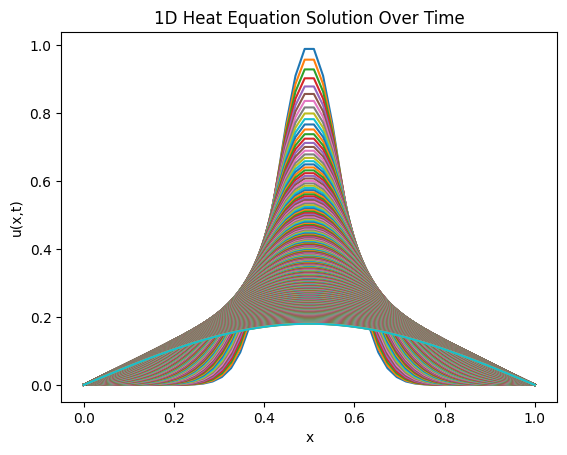

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
alpha = 1.0
nx = 50
dx = 1.0 / (nx - 1)
r = 0.4  # stability parameter
dt = r * dx * dx / alpha
nt = 400  # number of time steps

# grid and initial condition
x = np.linspace(0, 1, nx)
u_x_0 = np.exp(-100 * (x - 0.5)**2)  # u(x,0)=f(x): Gaussian peak

# time-stepping
u = np.zeros((nt, nx))
u[0] = u_x_0.copy()
for n in range(1, nt):
    u_t = np.zeros(nx)
    for i in range(1, nx-1):
        temp = u[n-1][i] + alpha * dt / dx**2 * (u[n-1][i+1] - 2*u[n-1][i] + u[n-1][i-1])
        u_t[i]=temp
    u[n] = u_t

for n in range(nt):
    plt.plot(x, u[n])
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('1D Heat Equation Solution Over Time')
plt.show()

**Implicit Crank–Nicolson:**

unconditionally stable: 
$$u^{n+1}=u^{n}+\frac{r}{2}(u_{xx}^{n+1}+u_{xx}^{n})$$
    
$$u_{i}^{n+1}-u_{i}^{n}=\frac{r}{2}\left[(u_{i+1}^{n+1}-2u_{i}^{n+1}+u_{i-1}^{n+1})+(u_{i+1}^{n}-2u_{i}^{n}+u_{i-1}^{n})\right]$$
leads to a tridiagonal linear system: 

$$Au^{n+1}=Bu^{n}$$

where

$$A=\begin{bmatrix}1+r&-\frac{r}{2}&0&\cdots &0 \\ -\frac{r}{2}&1+r&-\frac{r}{2}&\cdots &0 \\ 0&-\frac{r}{2}&1+r&\cdots &0 \\ \vdots &\ddots &\ddots &\ddots &-\frac{r}{2} \\ 0&0&0&-\frac{r}{2}&1+r\end{bmatrix}$$

$$B=\begin{bmatrix}1-r&\frac{r}{2}&0&\cdots &0 \\ \frac{r}{2}&1-r&\frac{r}{2}&\cdots &0 \\ 0&\frac{r}{2}&1-r&\ddots &0 \\ \vdots &\ddots &\ddots &\ddots &\frac{r}{2} \\ 0&0&0&\frac{r}{2}&1-r\end{bmatrix}$$
Thus: 
    
$$u^{n+1}=A^{-1}Bu^{n}$$

Text(0.5, 1.0, '1D Heat Equation Solution Over Time')

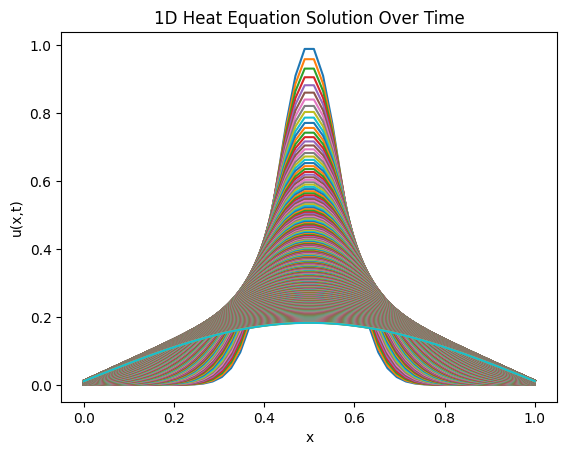

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
alpha = 1.0
r = 0.4  # stability parameter
nx = 50 # number of spatial points
nt = 400  # number of time steps
dx = 1.0/(nx-1)
dt = r*dx*dx/alpha

# grid and initial condition
x = np.linspace(0, 1, nx)
u_x_0 = np.exp(-100 * (x - 0.5)**2)  # u(x,0)=f(x): Gaussian peak

# build matrices A and B
A = np.zeros((nx, nx))
B = np.zeros((nx, nx))

for i in range(nx):
    A[i,i] = 1 + r
    if i > 0:
        A[i,i-1] = -r/2
    if i < nx-1:
        A[i,i+1] = -r/2

    B[i,i] = 1 - r
    if i > 0:
        B[i,i-1] = r/2
    if i < nx-1:
        B[i,i+1] = r/2

u = np.empty((0, nx))
u = np.vstack((u, u_x_0))
for _ in range(nt-1):
    u_t = np.linalg.solve(A, B @ u[-1])
    u = np.vstack((u, u_t))

for n in range(nt):
    plt.plot(x, u[n])
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('1D Heat Equation Solution Over Time')
plt.show()

2. Wave equation

Suppose $$u(x,t)$$ satisfies PDE

$$u_{tt}=c^{2}u_{xx}$$

with initial condition

$$u(x,0)=f(x)$$
$$u_t(x,0)=f(x)$$
$$u(0,t)=a(t)$$
$$u(1,t)=b(t)$$

Central-Time Central-Space, CTCS: 

$$u_{i}^{n+1}=2u_{i}^{n}-u_{i}^{n-1}+r^{2}(u_{i+1}^{n}-2u_{i}^{n}+u_{i-1}^{n})$$

where

$$r=c\frac{\Delta t}{\Delta x}$$

Stability constraint: 
$$r≤1$$

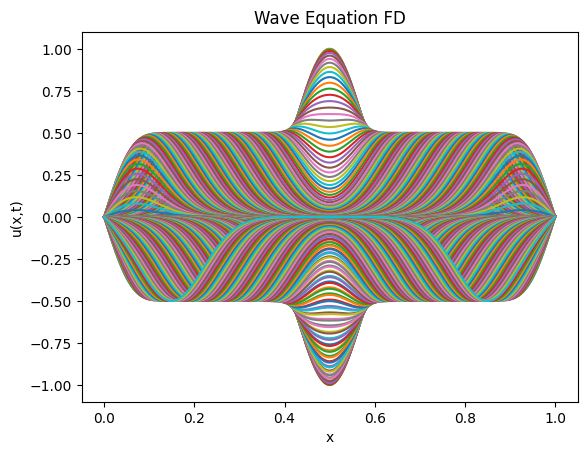

In [89]:
import numpy as np
import matplotlib.pyplot as plt

c = 1
r = 0.9
nx = 200
nt = 300
dx = 1/(nx-1)
dt = r*dx/c

x = np.linspace(0, 1, nx)
u_x_0 = np.exp(-100 * (x - 0.5)**2)

u = np.empty((nt, nx))
u[0] = u_x_0.copy()
u[1] = u_x_0.copy()

for n in range(2, nt):
    for i in range(1, nx-1):
        u[n][i] = (2*u[n-1][i] - u[n-2][i] + r**2 * (u[n-1][i+1] - 2*u[n-1][i] + u[n-1][i-1]))

for n in range(nt):
    plt.plot(x, u[n])
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Wave Equation FD')
plt.show()

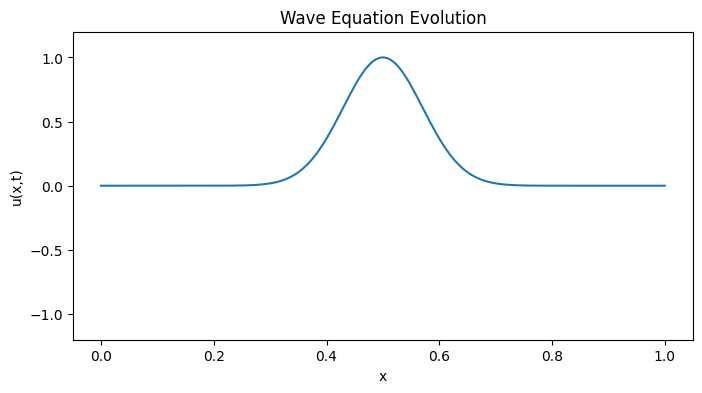

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

c = 1
r = 0.9
nx = 200
nt = 300
dx = 1/(nx-1)
dt = r*dx/c

x = np.linspace(0, 1, nx)
u_x_0 = np.exp(-100 * (x - 0.5)**2)

u = np.empty((nt, nx))
u[0] = u_x_0.copy()
u[1] = u_x_0.copy()

for n in range(2, nt):
    for i in range(1, nx-1):
        u[n][i] = (2*u[n-1][i] - u[n-2][i] + r**2 * (u[n-1][i+1] - 2*u[n-1][i] + u[n-1][i-1]))


fig, ax = plt.subplots(figsize=(8,4))
line, = ax.plot(x, u[0])
ax.set_ylim(-1.2, 1.2)
ax.set_title("Wave Equation Evolution")
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")

# -----------------------
# Update Function
# -----------------------
def update(frame):
    line.set_ydata(u[frame])
    return line,

# -----------------------
# Run animation
# -----------------------
ani = FuncAnimation(fig, update, frames=nt, interval=20, blit=True)
plt.show()

3. Poisson Equation (2D)

Suppose $$u(x,y)$$ satisfies PDE

$$u_{xx}+u_{yy}=f$$

with initial condition

$$u(x,0)=f(x)$$
$$u_x(x,0)=g(x)$$
$$u(0,y)=a(y)$$
$$u_y(0,y)=b(y)$$

Using Gauss-Seidel iteration:

$$u_{i,j}=\frac{1}{4}(u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}-h^{2}f_{i,j})$$

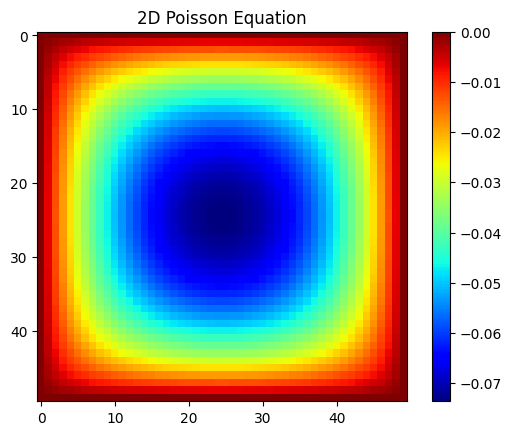

In [83]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
h = 1/(N-1)

u = np.zeros((N,N))
f = np.ones((N,N))  # RHS = 1 everywhere

for it in range(5000):
    for i in range(1, N-1):
        for j in range(1, N-1):
            u[i,j] = 0.25 * (u[i+1,j] + u[i-1,j] +
                             u[i,j+1] + u[i,j-1] -
                             h*h*f[i,j])

plt.imshow(u, cmap='jet')
plt.colorbar()
plt.title("2D Poisson Equation")
plt.show()

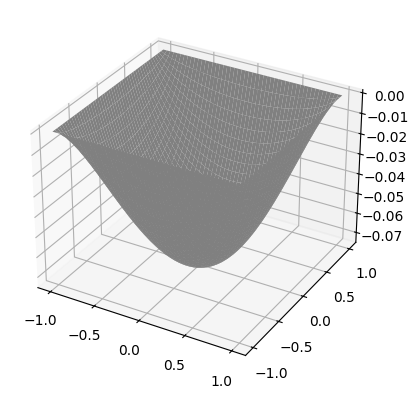

In [118]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
h = 1/(N-1)

u = np.zeros((N,N))
f = np.ones((N,N))  # RHS = 1 everywhere

for it in range(5000):
    for i in range(1, N-1):
        for j in range(1, N-1):
            u[i,j] = 0.25 * (u[i+1,j] + u[i-1,j] +
                             u[i,j+1] + u[i,j-1] -
                             h*h*f[i,j])

# Create grid
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)

# Plot surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d', alpha=0.3)
ax.plot_surface(X, Y, u, facecolor='grey')
plt.show()